In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

In [3]:
DATA_PATH = r"C:\Users\madhu\OneDrive\Documents\Restaurant_Reviews.tsv"

data = pd.read_csv(DATA_PATH, delimiter="\t", quoting=3)
print(data.head())
print("Shape:", data.shape)
print("Columns:", data.columns)

                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1
Shape: (1000, 2)
Columns: Index(['Review', 'Liked'], dtype='object')


In [4]:
nltk.download("stopwords")

# Keep negation words instead of stripping them - this is the key fix
# for reviews like "The food was not good" being misread as positive.
NEGATION_WORDS = {
    "not", "no", "nor", "don", "don't", "aren", "aren't", "couldn", "couldn't",
    "didn", "didn't", "doesn", "doesn't", "hadn", "hadn't", "hasn", "hasn't",
    "haven", "haven't", "isn", "isn't", "mightn", "mightn't", "mustn", "mustn't",
    "needn", "needn't", "shan", "shan't", "shouldn", "shouldn't", "wasn", "wasn't",
    "weren", "weren't", "won", "won't", "wouldn", "wouldn't", "but", "however",
}

STOP_WORDS = set(stopwords.words("english")) - NEGATION_WORDS
ps = PorterStemmer()
print("Stopwords kept:", len(STOP_WORDS), "| Negation words preserved:", len(NEGATION_WORDS))

Stopwords kept: 158 | Negation words preserved: 41


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\madhu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
def clean_review(raw_review: str) -> str:
    """Lowercase, strip non-letters, remove stopwords (but keep negations), stem."""
    review = re.sub(pattern="[^a-zA-Z]", repl=" ", string=raw_review)
    review = review.lower()
    words = review.split()
    words = [w for w in words if w not in STOP_WORDS]
    words = [ps.stem(w) for w in words]
    return " ".join(words)

# quick sanity check
print(clean_review("The food was not good at all!"))

food not good


In [6]:
corpus = [clean_review(review) for review in data["Review"]]
print(corpus[:5])

['wow love place', 'crust not good', 'not tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price']


In [7]:
cv = TfidfVectorizer(max_features=3000, ngram_range=(1, 3), sublinear_tf=True)
X = cv.fit_transform(corpus).toarray()
y = data.iloc[:, 1].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 3000)
y shape: (1000,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 3000), (200, 3000), (800,), (200,))

In [9]:
results = {}

def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    results[name] = {"model": model, "accuracy": acc, "y_pred": y_pred}
    print(f"\n---------- {name} ----------")
    print(f"Accuracy:  {round(acc * 100, 3)}%")
    print(f"Precision: {round(prec * 100, 3)}%")
    print(f"Recall:    {round(rec * 100, 3)}%")
    print(classification_report(y_te, y_pred, target_names=["Negative", "Positive"]))

In [10]:
best_accuracy, best_alpha = 0.0, 0.0
for alpha in np.arange(0.1, 1.1, 0.1):
    temp_clf = MultinomialNB(alpha=alpha)
    temp_clf.fit(X_train, y_train)
    score = accuracy_score(y_test, temp_clf.predict(X_test))
    print(f"NB Accuracy for alpha={round(alpha, 1)} is {round(score * 100, 3)}%")
    if score > best_accuracy:
        best_accuracy, best_alpha = score, alpha

print(f"\nBest NB alpha: {round(best_alpha, 1)} -> {round(best_accuracy * 100, 2)}%")

NB Accuracy for alpha=0.1 is 78.0%
NB Accuracy for alpha=0.2 is 79.0%
NB Accuracy for alpha=0.3 is 80.0%
NB Accuracy for alpha=0.4 is 80.5%
NB Accuracy for alpha=0.5 is 81.5%
NB Accuracy for alpha=0.6 is 82.5%
NB Accuracy for alpha=0.7 is 83.5%
NB Accuracy for alpha=0.8 is 82.0%
NB Accuracy for alpha=0.9 is 82.0%
NB Accuracy for alpha=1.0 is 82.5%

Best NB alpha: 0.7 -> 83.5%


In [11]:
nb_classifier = MultinomialNB(alpha=best_alpha)
nb_classifier.fit(X_train, y_train)
evaluate("Multinomial Naive Bayes", nb_classifier, X_test, y_test)


---------- Multinomial Naive Bayes ----------
Accuracy:  83.5%
Precision: 85.0%
Recall:    82.524%
              precision    recall  f1-score   support

    Negative       0.82      0.85      0.83        97
    Positive       0.85      0.83      0.84       103

    accuracy                           0.83       200
   macro avg       0.83      0.84      0.83       200
weighted avg       0.84      0.83      0.84       200



In [12]:
log_reg = LogisticRegression(max_iter=1000, C=1.0)
log_reg.fit(X_train, y_train)
evaluate("Logistic Regression", log_reg, X_test, y_test)


---------- Logistic Regression ----------
Accuracy:  80.5%
Precision: 89.024%
Recall:    70.874%
              precision    recall  f1-score   support

    Negative       0.75      0.91      0.82        97
    Positive       0.89      0.71      0.79       103

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.80       200
weighted avg       0.82      0.81      0.80       200



In [13]:
svm_classifier = LinearSVC()
svm_classifier.fit(X_train, y_train)
evaluate("Linear SVM", svm_classifier, X_test, y_test)


---------- Linear SVM ----------
Accuracy:  81.5%
Precision: 85.87%
Recall:    76.699%
              precision    recall  f1-score   support

    Negative       0.78      0.87      0.82        97
    Positive       0.86      0.77      0.81       103

    accuracy                           0.81       200
   macro avg       0.82      0.82      0.81       200
weighted avg       0.82      0.81      0.81       200



In [14]:
best_name = max(results, key=lambda k: results[k]["accuracy"])
classifier = results[best_name]["model"]
print(f">>> Using best model for predictions: {best_name} "
      f"({round(results[best_name]['accuracy'] * 100, 2)}% accuracy)")

>>> Using best model for predictions: Multinomial Naive Bayes (83.5% accuracy)


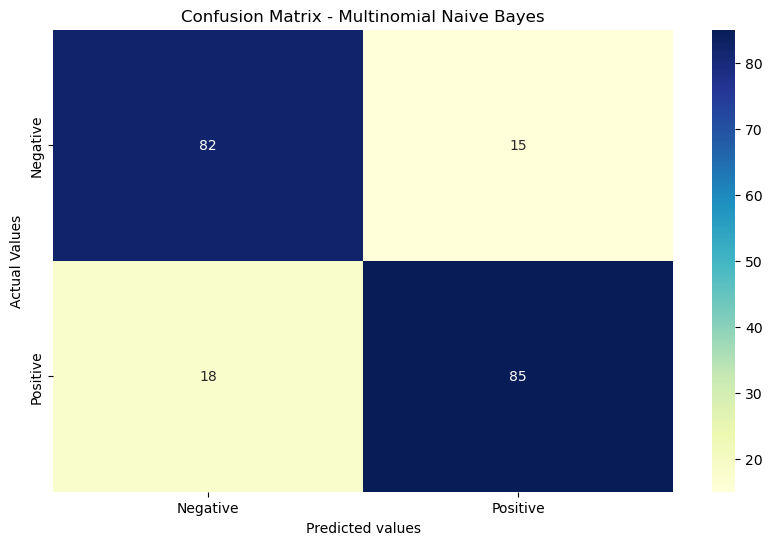

In [15]:
cm = confusion_matrix(y_test, results[best_name]["y_pred"])
plt.figure(figsize=(10, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlGnBu",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
plt.xlabel("Predicted values")
plt.ylabel("Actual Values")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

In [16]:
def predict_sentiment(sample_review: str):
    cleaned = clean_review(sample_review)
    vec = cv.transform([cleaned]).toarray()
    return classifier.predict(vec)[0]

def show_prediction(sample_review: str):
    label = predict_sentiment(sample_review)
    print(f"'{sample_review}' -> {'Positive' if label else 'Negative'} review")

In [17]:
show_prediction("The food is really bad.")
show_prediction("Food was pretty bad and the service was very slow")
show_prediction("The food was absolutely wonderful, from preparation to presentation, very pleasing.")
show_prediction("food average")

'The food is really bad.' -> Negative review
'Food was pretty bad and the service was very slow' -> Negative review
'The food was absolutely wonderful, from preparation to presentation, very pleasing.' -> Positive review
'food average' -> Negative review


In [18]:
show_prediction("Oh great, another hour wait for cold food. Just perfect.")
show_prediction("Yeah, this is exactly the kind of service I love, waiting forever.")
show_prediction("Wow, what a wonderful experience, waited 2 hours for a stale sandwich.")

'Oh great, another hour wait for cold food. Just perfect.' -> Positive review
'Yeah, this is exactly the kind of service I love, waiting forever.' -> Positive review
'Wow, what a wonderful experience, waited 2 hours for a stale sandwich.' -> Negative review
